<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/Xayne's-RF-(Random-Forest)/Xayne's_Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A: The Model - Random Forest**

Data Loading & Cleaning

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
# Load the file
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|', on_bad_lines='skip', engine='python')

# --- FIX: CLEAN COLUMN NAMES ---
# The file has "Log_Income,," as a header. This fixes it.
df.columns = df.columns.str.replace(',,', '').str.strip()

# Cleanup: Remove accidental empty columns (trailing commas)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows where Target is missing
df = df.dropna(subset=['Default_Status'])
df['Default_Status'] = df['Default_Status'].astype(int)

Feature Selection

In [15]:
# ==========================================
# 2. SELECT FEATURES
# ==========================================
features = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Loan_Amount',
    'Loan_Term_Months',
    'DTI_Ratio',
    'Log_Income',
    'Risk_Flag',
    'Occupation',
    'Has_Asset'
]

# Create X (Features) and y (Target)
X = df[features].copy()
y = df['Default_Status']

Preprocessing

In [10]:
# ==========================================
# 3. PREPROCESSING
# ==========================================
# Identify truly numeric columns that are not handled separately
numeric_cols_for_conversion = [col for col in features if col not in ['Occupation', 'Has_Asset']]

# Convert these columns to numeric, coercing errors to NaN
for col in numeric_cols_for_conversion:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Encode Occupation (Text -> Numbers)
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# Encode Asset (Yes/No -> 1/0)
if 'Has_Asset' in X.columns:
    X['Has_Asset'] = pd.to_numeric(X['Has_Asset'].replace({'Yes': 1, 'No': 0}), errors='coerce').fillna(0)

# Fill any remaining missing values (from coerce or original NaNs) with 0
X = X.fillna(0)

Model Training - Before Hypertuning

⏳ Training Baseline Random Forest...

📊 BASELINE MODEL EVALUATION (Before Tuning)
---------------------------------------
1. Accuracy:  84.47%  (Baseline)
2. F1-Score:  0.8046
3. Recall:    76.09%  (Catching Defaulters)
4. ROC-AUC:   0.8602
---------------------------------------


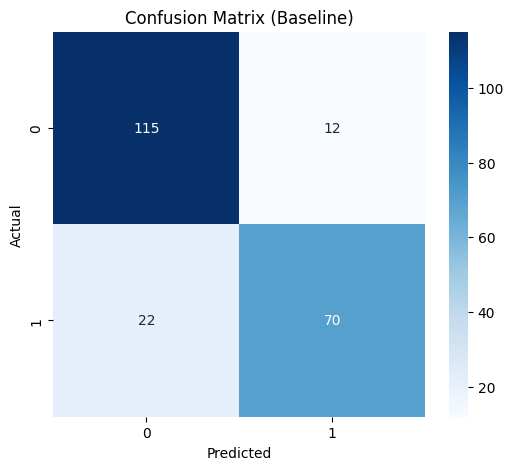


Detailed Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       127
           1       0.85      0.76      0.80        92

    accuracy                           0.84       219
   macro avg       0.85      0.83      0.84       219
weighted avg       0.85      0.84      0.84       219



In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. TRAIN BASELINE MODEL (Default Settings)
# ==========================================
# We use standard settings: n_estimators=100, no depth limits
print("⏳ Training Baseline Random Forest...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# ==========================================
# 2. EVALUATE BASELINE
# ==========================================
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

# --- A. THE "BIG 4" METRICS TABLE ---
acc = accuracy_score(y_test, y_pred_base)
f1 = f1_score(y_test, y_pred_base)
recall = recall_score(y_test, y_pred_base)
auc = roc_auc_score(y_test, y_prob_base)

print("\n📊 BASELINE MODEL EVALUATION (Before Tuning)")
print(f"---------------------------------------")
print(f"1. Accuracy:  {acc:.2%}  (Baseline)")
print(f"2. F1-Score:  {f1:.4f}")
print(f"3. Recall:    {recall:.2%}  (Catching Defaulters)")
print(f"4. ROC-AUC:   {auc:.4f}")
print(f"---------------------------------------")

# --- B. VISUALIZATIONS ---
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- C. DETAILED REPORT ---
print("\nDetailed Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base))

Model Training - After Hypertuning

In [11]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# 4. OPTIMIZED MODEL TRAINING (Hyperparameter Tuning)
# ==========================================
print("⏳ Starting Grid Search to find best parameters...")

# 1. Define the "Grid" of settings to test
param_grid = {
    'n_estimators': [100, 200],        # Try 100 and 200 trees
    'max_depth': [None, 10, 20],       # Try limiting depth to prevent overfitting
    'min_samples_split': [2, 5, 10],   # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples at a leaf
}

# 2. Setup the Grid Search
# cv=3 means it splits data into 3 parts to cross-validate (very robust)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # Use all CPU cores
    scoring='accuracy',
    verbose=1
)

# 3. Train on all combinations
grid_search.fit(X_train, y_train)

# 4. Get the Winner
best_rf_model = grid_search.best_estimator_

print(f"✅ Best Parameters Found: {grid_search.best_params_}")
print(f"✅ Best Training Accuracy (CV): {grid_search.best_score_:.2%}")

# IMPORTANT: From now on, use 'best_rf_model' instead of 'rf_model'

⏳ Starting Grid Search to find best parameters...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
✅ Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
✅ Best Training Accuracy (CV): 90.60%


Evaluation

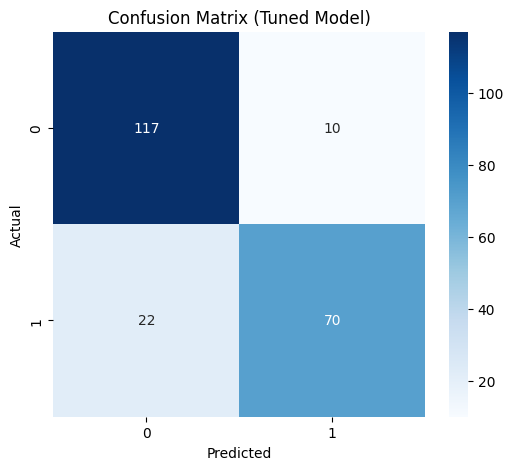


📊 FINAL MODEL EVALUATION (Tuned Random Forest)
---------------------------------------
1. Accuracy:  85.39%  (Overall correctness)
2. F1-Score:  0.8140  (Balance of Precision/Recall)
3. Recall:    76.09%  (How many defaulters we caught)
4. ROC-AUC:   0.8607  (Discrimination ability)
---------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       127
           1       0.88      0.76      0.81        92

    accuracy                           0.85       219
   macro avg       0.86      0.84      0.85       219
weighted avg       0.86      0.85      0.85       219



In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 5. EVALUATE THE TUNED MODEL
# ==========================================
# Use the optimized model (best_rf_model) for predictions
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]  # Probability needed for ROC-AUC

# --- A. VISUALIZATIONS ---
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- B. THE "BIG 4" METRICS TABLE ---
# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n📊 FINAL MODEL EVALUATION (Tuned Random Forest)")
print(f"---------------------------------------")
print(f"1. Accuracy:  {acc:.2%}  (Overall correctness)")
print(f"2. F1-Score:  {f1:.4f}  (Balance of Precision/Recall)")
print(f"3. Recall:    {recall:.2%}  (How many defaulters we caught)")
print(f"4. ROC-AUC:   {auc:.4f}  (Discrimination ability)")
print(f"---------------------------------------")

# --- C. DETAILED REPORT ---
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Feature Importance

In [14]:
# Feature Importance
print("\n🏆 Top Predictors (Tuned):")
# We access feature_importances_ from the best estimator
print(pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5))


🏆 Top Predictors (Tuned):
DTI_Ratio        0.390437
Risk_Flag        0.289130
Loan_Amount      0.097824
Annual_Income    0.054992
Credit_Score     0.048020
dtype: float64


# **Part B: The LLM Analysis (The Insight)**
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [16]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [22]:
# ==========================================
# 1. PREPARE DATA FOR PROMPT
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Calculate specific metrics for the Tuned Random Forest
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1] # Probability needed for ROC-AUC

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred), # Critical for catching defaulters
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

# Extract Top 5 Features (Random Forest specific)
# Fix: Use X_train.columns (or X_test.columns) as the index
# because best_rf_model was trained on X_train after preprocessing (one-hot encoding).
importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(5)
top_features_str = "\n".join([f"- {name}: {score:.4f}" for name, score in top_features.items()])

# ==========================================
# 2. THE PROMPT
# ==========================================
prompt = f"""
You are a Senior Credit Risk Analyst and Data Science Consultant.
I have trained a Random Forest Classifier on a financial dataset to predict loan defaults.
Below are the actual performance metrics and the most important features identified by the model.

### 1. MODEL PERFORMANCE:
- Accuracy: {metrics['accuracy']:.2%}
- Precision: {metrics['precision']:.2%}
- Recall (Sensitivity): {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC Score: {metrics['roc_auc']:.2%}

### 2. TOP PREDICTIVE FEATURES:
{top_features_str}

### YOUR TASK:
Please write a professional "Model Evaluation Report" covering the following:

1. **Executive Summary**: Is this model effective for risk management? (Focus on the trade-off between Precision and Recall).
2. **Feature Interpretation**: Explain *why* the top features listed above (e.g., DTI_Ratio, Risk_Flag) are physically predictive of a borrower defaulting. connect this to financial logic.
3. **Strategic Recommendations**: Based on these findings, what one specific action should the bank take to reduce defaults?
4. **Limitations**: Mention any potential risks of relying on a Random Forest (e.g., historical bias).

Format the response in a clear, structured, professional report style suitable for a bank executive.
"""

# Test: Print it to see how it looks
print(prompt)


You are a Senior Credit Risk Analyst and Data Science Consultant.
I have trained a Random Forest Classifier on a financial dataset to predict loan defaults.
Below are the actual performance metrics and the most important features identified by the model.

### 1. MODEL PERFORMANCE:
- Accuracy: 85.39%
- Precision: 87.50%
- Recall (Sensitivity): 76.09%
- F1-score: 81.40%
- ROC-AUC Score: 86.07%

### 2. TOP PREDICTIVE FEATURES:
- DTI_Ratio: 0.3904
- Risk_Flag: 0.2891
- Loan_Amount: 0.0978
- Annual_Income: 0.0550
- Credit_Score: 0.0480

### YOUR TASK:
Please write a professional "Model Evaluation Report" covering the following:

1. **Executive Summary**: Is this model effective for risk management? (Focus on the trade-off between Precision and Recall).
2. **Feature Interpretation**: Explain *why* the top features listed above (e.g., DTI_Ratio, Risk_Flag) are physically predictive of a borrower defaulting. connect this to financial logic.
3. **Strategic Recommendations**: Based on these fin

In [23]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)


In [24]:
# ==========================================
# PART C: GENERATE WITH GEMINI
# ==========================================
print("🤖 Generating Analysis with Gemini...")

# Generation Config (Your settings were good!)
generation_config = {
    "max_output_tokens": 20000,  # 2k is plenty for a report (20k is overkill/safe)
    "temperature": 0.7,
}

# Generate
response = model.generate_content(prompt, generation_config=generation_config)

# ==========================================
# PART D: DISPLAY OUTPUT
# ==========================================
if response.text:
    print("\n" + "="*50)
    print("📝 GEMINI AUTOMATED FINDINGS")
    print("="*50)
    print(response.text)
else:
    print("No response received. Check safety settings.")

🤖 Generating Analysis with Gemini...

📝 GEMINI AUTOMATED FINDINGS
## Model Evaluation Report: Loan Default Prediction Model

**To:** Executive Leadership, Risk Management Committee
**From:** [Your Name/Department], Senior Credit Risk Analyst & Data Science Consultant
**Date:** October 26, 2023
**Subject:** Evaluation of Random Forest Classifier for Loan Default Prediction

---

### 1. Executive Summary

This report evaluates the performance of a recently trained Random Forest Classifier designed to predict loan defaults. The model demonstrates strong overall performance with an **Accuracy of 85.39%** and a **ROC-AUC Score of 86.07%**, indicating its general capability to distinguish between defaulting and non-defaulting borrowers.

A critical aspect for risk management is the trade-off between Precision and Recall for the positive class (loan default).
*   **Precision (87.50%)**: When the model predicts a loan will default, it is correct 87.50% of the time. This means the model is high